<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/dz_topic_4_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

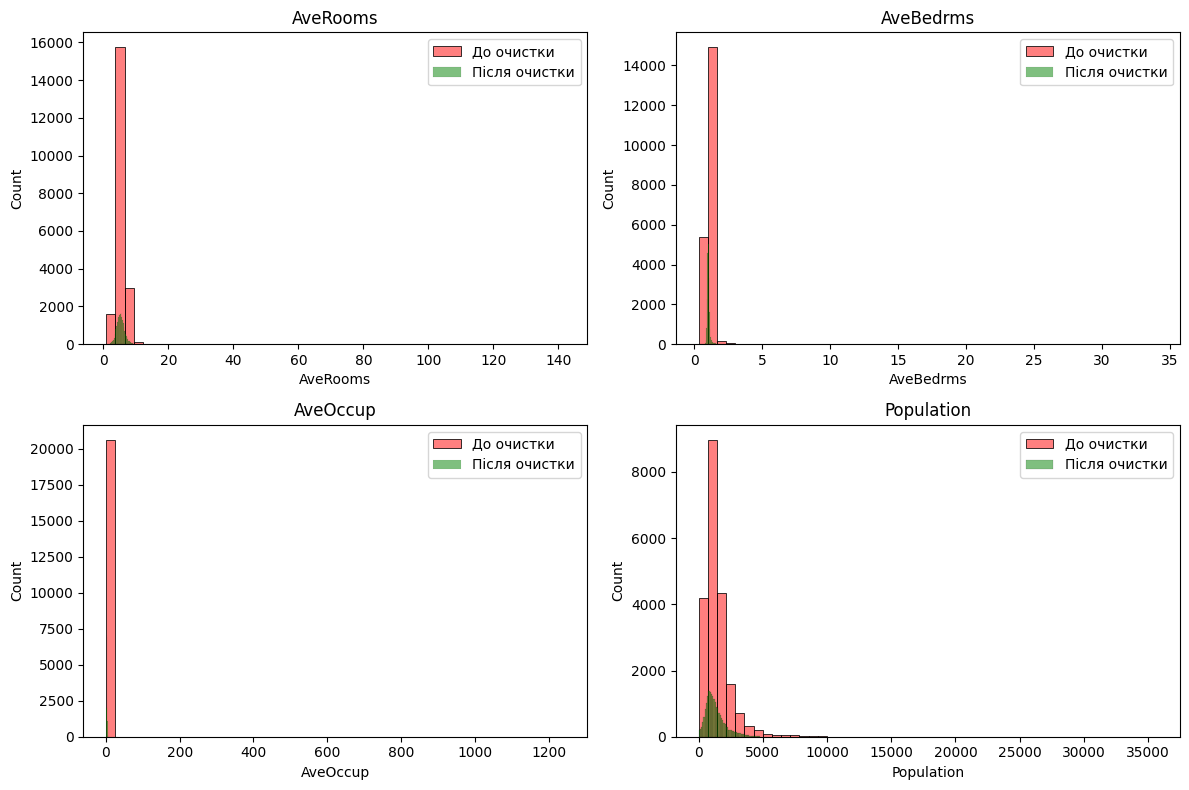

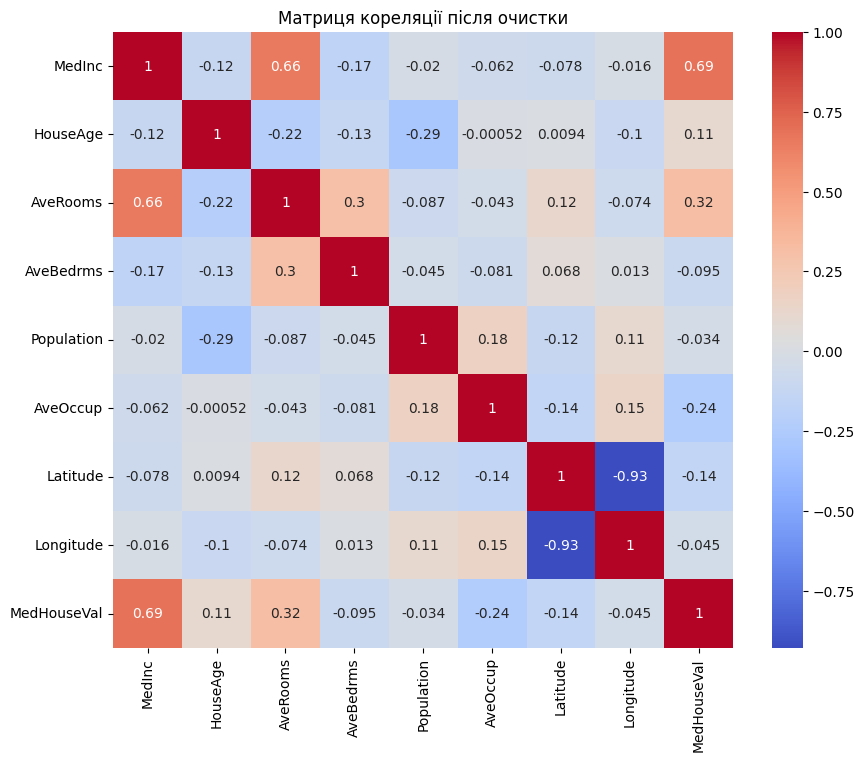

R2: 0.64 | MAE: 0.51 | MAPE: 0.30


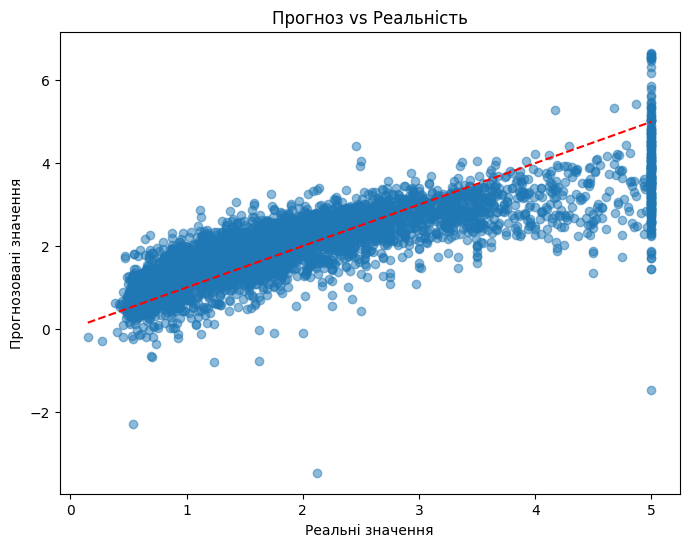

In [1]:
# 1. Імпорт пакетів
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import zscore

# 2. Завантаження датасету California Housing
data = fetch_california_housing(as_frame=True)
df = data.frame

# 3.1. Очистка від викидів
cols_outliers = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']
z_scores = df[cols_outliers].apply(zscore)
mask = (np.abs(z_scores) < 3).all(axis=1)
df_clean = df[mask]

# Візуалізація розподілу до/після очистки
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for i, col in enumerate(cols_outliers):
    sns.histplot(df[col], bins=50, ax=axes[i//2, i%2], color='red', alpha=0.5, label='До очистки')
    sns.histplot(df_clean[col], bins=50, ax=axes[i//2, i%2], color='green', alpha=0.5, label='Після очистки')
    axes[i//2, i%2].set_title(col)
    axes[i//2, i%2].legend()
plt.tight_layout()
plt.show()

# 3.2. Кореляція
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Матриця кореляції після очистки")
plt.show()

# Видалення ознаки з високою кореляцією
df_clean = df_clean.drop(columns=['AveBedrms'])

# 4. Train/test split
X = df_clean.drop(columns=['MedHouseVal'])
y = df_clean['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Нормалізація
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Модель
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 7. Метрики
y_pred = model.predict(X_test_scaled)
r_sq_upd = model.score(X_train_scaled, y_train)
mae_upd = mean_absolute_error(y_test, y_pred)
mape_upd = mean_absolute_percentage_error(y_test, y_pred)

print(f'R2: {r_sq_upd:.2f} | MAE: {mae_upd:.2f} | MAPE: {mape_upd:.2f}')

# 8. Візуалізація прогнозів vs реальні значення
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Реальні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Прогноз vs Реальність")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()
